<a href="https://colab.research.google.com/github/krishnaro437-cyber/An-lisis-de-Riesgo-Crediticio-con-ML/blob/main/Limite_de_credito_bancario2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importar base de datos**

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [146]:
df = pd.read_csv('/content/drive/MyDrive/P/credito.csv')

In [147]:
df.head()

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,"12.691,51","1.144,90",42
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,"8.256,96","1.291,45",33
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,"3.418,56","1.887,72",20
3,769911858,0,40,F,4,ensino medio,na,menos que $40K,blue,34,3,1,4,"3.313,03","1.171,56",20
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,"4.716,22","816,08",28


In [148]:
df.shape

(10127, 16)

# **Limpieza de datos**

In [149]:
# Traducir las columnas
df = df.rename(columns={df.columns[2]: "edad", df.columns[4]:"dependientes", df.columns[5]: "escolaridad", df.columns[8]: "tipo_de_tarjeta",df.columns[9]:"meses_de_relacionamiento",df.columns[10]: "cantidad_de_productos", df.columns[11]: "interacciones_12m",df.columns[12]: "meses_inactivo_12m",df.columns[14]: "valor_transacciones_12m", df.columns[15]:"cantidad_trans_12m"})


In [150]:
categorical_cols = ['sexo', 'escolaridad', 'estado_civil', 'tipo_de_tarjeta']
num_cols = ['id', 'default', 'edad', 'dependientes', 'salario_anual', 'meses_de_relacionamiento', 'cantidad_de_productos', 'interacciones_12m', 'meses_inactivo_12m', 'limite_credito', 'valor_transacciones_12m', 'cantidad_trans_12m']

In [151]:
# Imprimir valores únicos de las columnas categóricas
for col in categorical_cols:
    print(f'columna {col}: {df[col].nunique()}, {df[col].unique()}')


columna sexo: 2, ['M' 'F']
columna escolaridad: 6, ['ensino medio' 'mestrado' 'sem educacao formal' 'na' 'graduacao'
 'doutorado']
columna estado_civil: 4, ['casado' 'solteiro' 'na' 'divorciado']
columna tipo_de_tarjeta: 4, ['blue' 'gold' 'silver' 'platinum']


In [152]:
# Traducción
df['estado_civil']= df['estado_civil'].replace('solteiro', 'soltero')
df['escolaridad']= df['escolaridad'].replace('ensino medio', 'secundaria')
df['escolaridad']= df['escolaridad'].replace('mestrado', 'maestria')
df['escolaridad']= df['escolaridad'].replace('sem educacao formal', 'sin educacion formal')
df['escolaridad']= df['escolaridad'].replace('graduacao', 'licenciatura')
df['escolaridad']= df['escolaridad'].replace('doutorado', 'doctorado')




In [153]:
# Valores faltantes por variable
for col in (df.columns):
  print(f'columna {col}: {sum(df[col]== 'na')} valores faltantes')

columna id: 0 valores faltantes
columna default: 0 valores faltantes
columna edad: 0 valores faltantes
columna sexo: 0 valores faltantes
columna dependientes: 0 valores faltantes
columna escolaridad: 1519 valores faltantes
columna estado_civil: 749 valores faltantes
columna salario_anual: 1112 valores faltantes
columna tipo_de_tarjeta: 0 valores faltantes
columna meses_de_relacionamiento: 0 valores faltantes
columna cantidad_de_productos: 0 valores faltantes
columna interacciones_12m: 0 valores faltantes
columna meses_inactivo_12m: 0 valores faltantes
columna limite_credito: 0 valores faltantes
columna valor_transacciones_12m: 0 valores faltantes
columna cantidad_trans_12m: 0 valores faltantes


In [154]:
#calcular la moda de estado civil para cada edad
moda_estado_civil = df.groupby('edad')['estado_civil'].apply(lambda x: x.mode().iloc[0])

#calcular la moda en escolaridad con respecto a la edad
moda_escolaridad = df.groupby('edad')['escolaridad'].apply(lambda x: x.mode().iloc[0])

In [155]:
# Imputar la moda con respecto a la edad
df.loc[df['estado_civil'] == 'na', 'estado_civil'] = df.loc[df['estado_civil'] == 'na', 'edad'].apply(lambda x: moda_estado_civil[x])
df.loc[df['escolaridad'] == 'na', 'escolaridad'] = df.loc[df['escolaridad'] == 'na', 'edad'].apply(lambda x: moda_escolaridad[x])

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        10127 non-null  int64 
 1   default                   10127 non-null  int64 
 2   edad                      10127 non-null  int64 
 3   sexo                      10127 non-null  object
 4   dependientes              10127 non-null  int64 
 5   escolaridad               10127 non-null  object
 6   estado_civil              10127 non-null  object
 7   salario_anual             10127 non-null  object
 8   tipo_de_tarjeta           10127 non-null  object
 9   meses_de_relacionamiento  10127 non-null  int64 
 10  cantidad_de_productos     10127 non-null  int64 
 11  interacciones_12m         10127 non-null  int64 
 12  meses_inactivo_12m        10127 non-null  int64 
 13  limite_credito            10127 non-null  object
 14  valor_transacciones_12

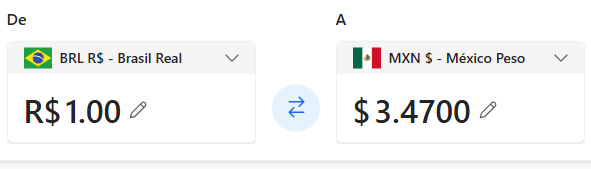

In [157]:
#valores unicos en salario
df['salario_anual'].unique()

array(['$60K - $80K', 'menos que $40K', '$80K - $120K', '$40K - $60K',
       '$120K +', 'na'], dtype=object)

In [158]:
#funcion para limpiar limite_credito y  valor_transacciones_12m
def limpiar_y_convertir_numerico(valor):
    if isinstance(valor, str):
        valor_limpio = valor.replace('.', '').replace(',', '.')
        # Convertir a float
        try:
            return float(valor_limpio)*3.47
        except ValueError:
            return None
    else:
        return None

# Funcion para limpiar la columna salario_anual
def limpiar_salario_anual(valor):
    if isinstance(valor, str):
        valor_limpio = valor.replace('$', '').replace('K', '').replace('menos que', '').strip()
        if '-' in valor_limpio:
            low, high = map(float, valor_limpio.split('-'))
            return (low + high) / 2 * 1000 * 3.47
        elif '+' in valor_limpio:
            return float(valor_limpio.replace('+', '')) * 1000 * 3.47
        else:
            try:
                return float(valor_limpio) * 1000 * 3.47
            except ValueError:
                return None
    else:
        return None

In [159]:
# Aplicar la función a las columnas correspondientes
df['valor_transacciones_12m'] = df['valor_transacciones_12m'].apply(limpiar_y_convertir_numerico)
df['limite_credito'] = df['limite_credito'].apply(limpiar_y_convertir_numerico)
df['salario_anual'] = df['salario_anual'].apply(limpiar_salario_anual)

In [160]:
df.head()

,id,default,edad,sexo,dependientes,escolaridad,estado_civil,salario_anual,tipo_de_tarjeta,meses_de_relacionamiento,cantidad_de_productos,interacciones_12m,meses_inactivo_12m,limite_credito,valor_transacciones_12m,cantidad_trans_12m
0,768805383,0,45,M,3,secundaria,casado,242900.0,blue,39,5,3,1,44039.5397,3972.8030,42
1,818770008,0,49,F,5,maestria,soltero,138800.0,blue,44,6,2,1,28651.6512,4481.3315,33
2,713982108,0,51,M,3,maestria,casado,347000.0,blue,36,4,0,1,11862.4032,6550.3884,20
3,769911858,0,40,F,4,secundaria,casado,138800.0,blue,34,3,1,4,11496.2141,4065.3132,20
4,709106358,0,40,M,3,sin educacion formal,casado,242900.0,blue,21,5,0,1,16365.2834,2831.7976,28


In [161]:
#salario minimo al año en el 2023: $2732 Euros aprox 58, 437.48
#corroborar tener valores lógicos en salario anual
min(df['salario_anual'])

138800.0

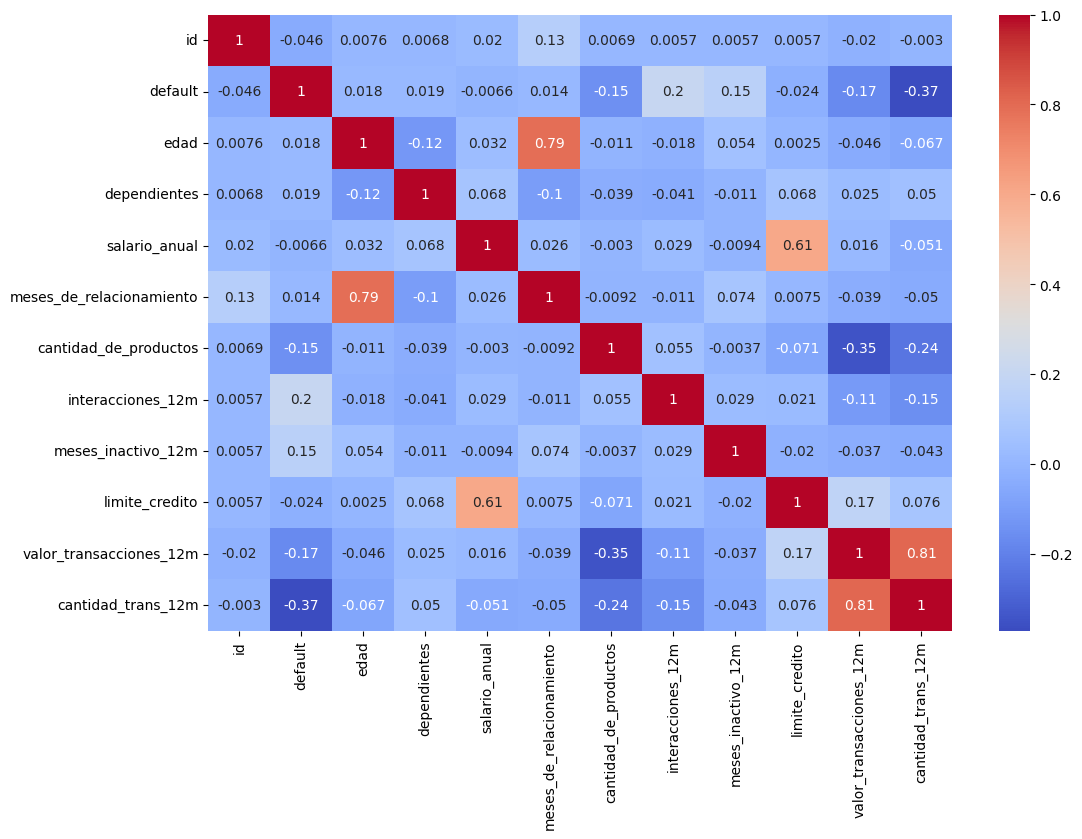

In [162]:
# observar la correlacion más alta para aproximar los salrios anuales faltantes
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [163]:
# calcular la media de salarios con respecto al limite de crédito
media_salario = df.groupby(['limite_credito'])['salario_anual'].mean()

In [164]:
# aplicar
df.loc[df['salario_anual'] == 'na', 'salario_anual'] = df.loc[df['salario_anual'] == 'na', 'limite_credito'].apply(lambda x: media_salario[x])

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        10127 non-null  int64  
 1   default                   10127 non-null  int64  
 2   edad                      10127 non-null  int64  
 3   sexo                      10127 non-null  object 
 4   dependientes              10127 non-null  int64  
 5   escolaridad               10127 non-null  object 
 6   estado_civil              10127 non-null  object 
 7   salario_anual             9015 non-null   float64
 8   tipo_de_tarjeta           10127 non-null  object 
 9   meses_de_relacionamiento  10127 non-null  int64  
 10  cantidad_de_productos     10127 non-null  int64  
 11  interacciones_12m         10127 non-null  int64  
 12  meses_inactivo_12m        10127 non-null  int64  
 13  limite_credito            10127 non-null  float64
 14  valor_

In [166]:
df.drop_duplicates(inplace=True)

In [167]:
df.dropna(inplace=True)

In [168]:
df


,id,default,edad,sexo,dependientes,escolaridad,estado_civil,salario_anual,tipo_de_tarjeta,meses_de_relacionamiento,cantidad_de_productos,interacciones_12m,meses_inactivo_12m,limite_credito,valor_transacciones_12m,cantidad_trans_12m
0,768805383,0,45,M,3,secundaria,casado,242900.0,blue,39,5,3,1,44039.5397,3972.8030,42
1,818770008,0,49,F,5,maestria,soltero,138800.0,blue,44,6,2,1,28651.6512,4481.3315,33
2,713982108,0,51,M,3,maestria,casado,347000.0,blue,36,4,0,1,11862.4032,6550.3884,20
3,769911858,0,40,F,4,secundaria,casado,138800.0,blue,34,3,1,4,11496.2141,4065.3132,20
4,709106358,0,40,M,3,sin educacion formal,casado,242900.0,blue,21,5,0,1,16365.2834,2831.7976,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,0,50,M,2,maestria,soltero,173500.0,blue,40,3,3,2,13893.5677,53702.6222,117
10123,710638233,1,41,M,2,maestria,divorciado,173500.0,blue,25,4,3,2,14841.3288,30414.1336,69
10124,716506083,1,44,F,1,secundaria,casado,138800.0,blue,36,5,4,3,18769.7852,35712.4766,60
10125,717406983,1,30,M,2,maestria,casado,173500.0,blue,36,4,3,3,18327.9848,29132.8014,62


#**Análizis descriptivo**

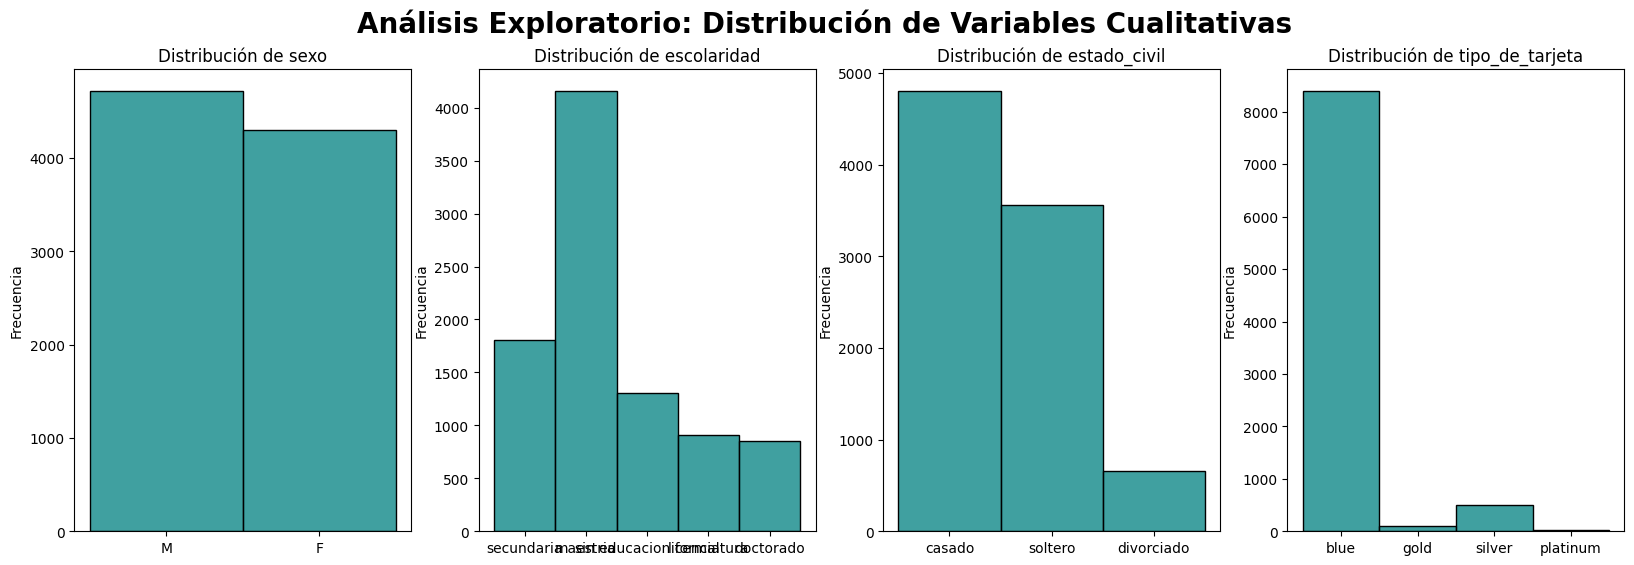

In [169]:
#visualizacion de los datos categoricos del df_limpio
categorical_cols = ['sexo', 'escolaridad', 'estado_civil', 'tipo_de_tarjeta']

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Análisis Exploratorio: Distribución de Variables Cualitativas', fontsize=20, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.histplot(df[col],  ax=axes[i], color='teal')
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.show()


In [170]:
# Eliminar tarjetas gold, silver platinum
df = df[~df['tipo_de_tarjeta'].isin(['platinum', 'gold', 'silver'])]

In [171]:
#Juntar en la categoria de estado civil a los divorciados y no casados en una sola vategoria llamada no casados
df['estado_civil'] = df['estado_civil'].replace(['divorciado', 'soltero'], 'no casado')

/tmp/ipython-input-1886259144.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['estado_civil'] = df['estado_civil'].replace(['divorciado', 'soltero'], 'no casado')


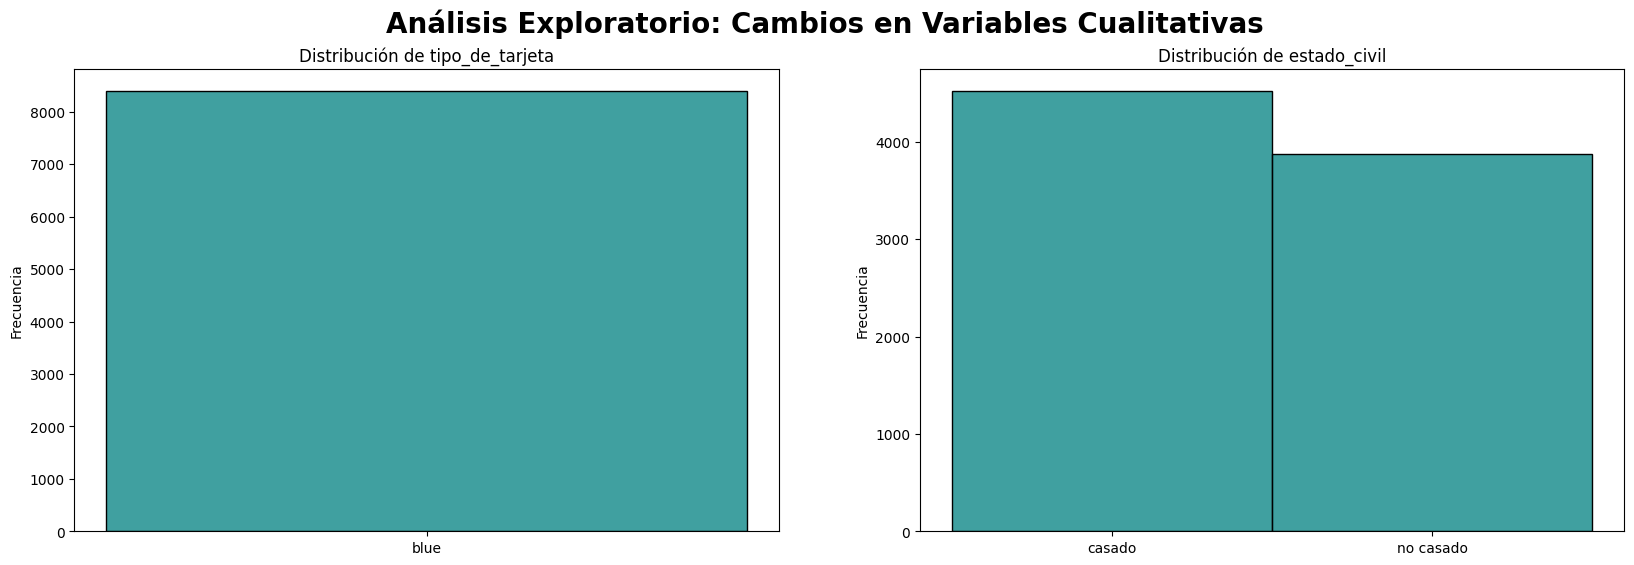

In [172]:
# visualizar cambios en tipo de tarjeta y estado civil
categorical_cols = ['tipo_de_tarjeta', 'estado_civil']

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Análisis Exploratorio: Cambios en Variables Cualitativas', fontsize=20, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.histplot(df[col],  ax=axes[i], color='teal')
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.show()

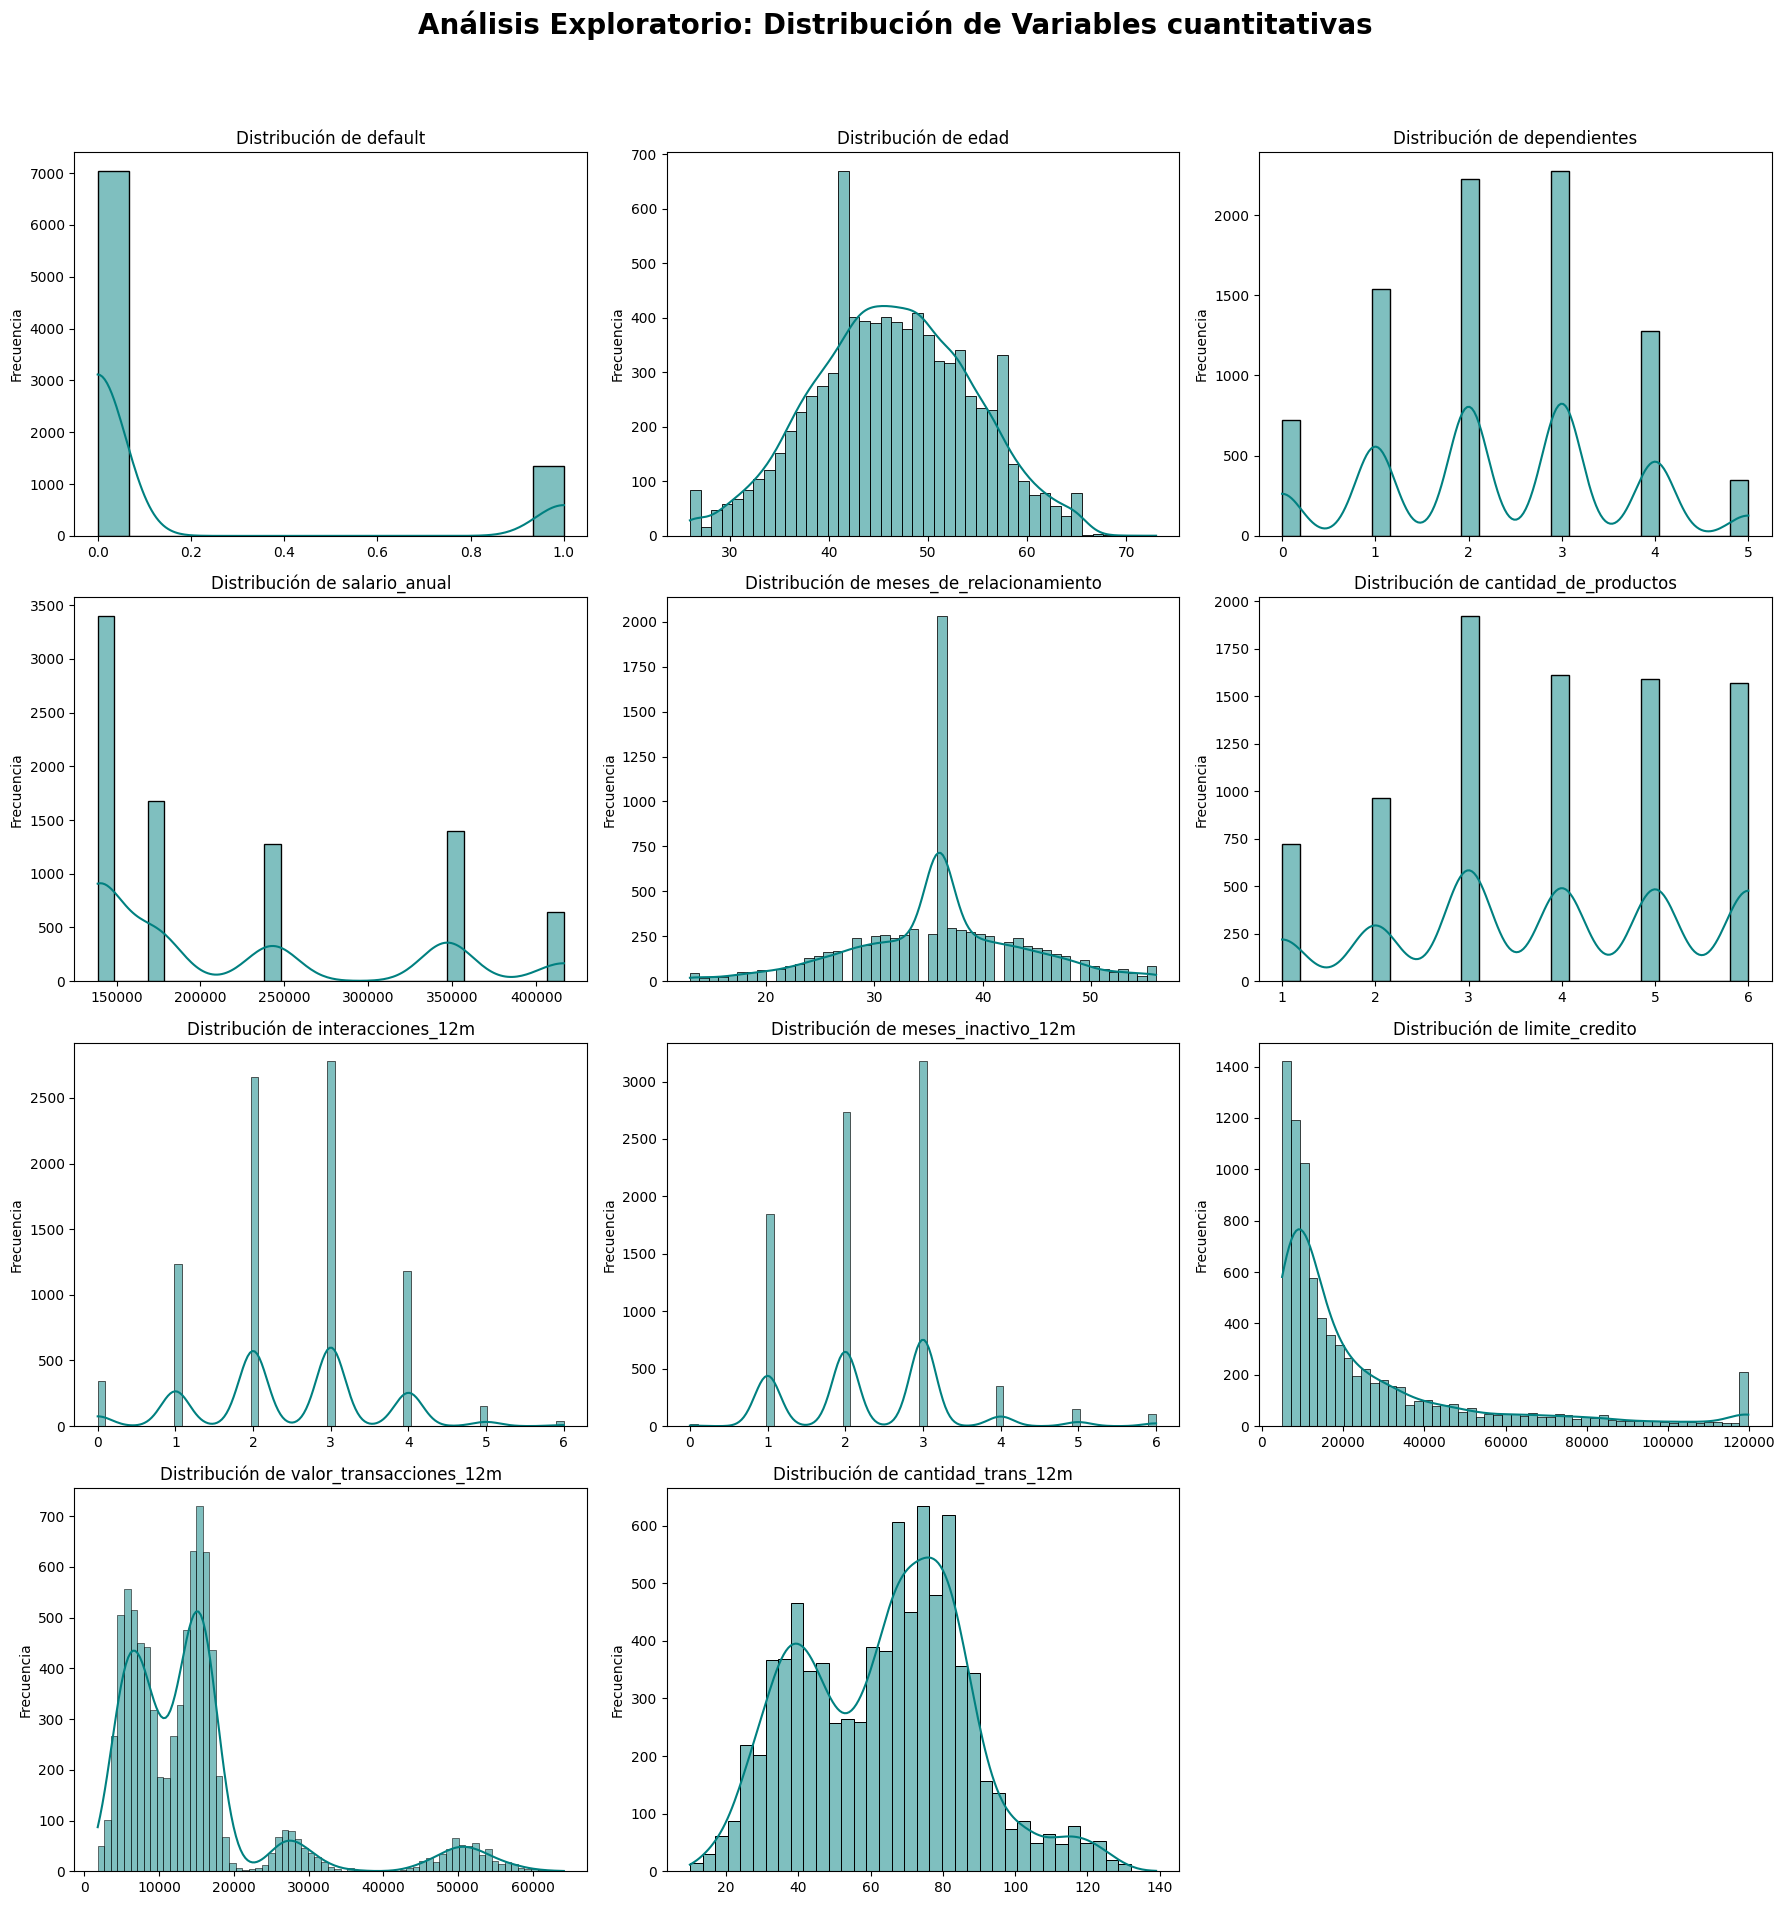

In [173]:
# Histogramas para numéricas
num_cols = ['default', 'edad', 'dependientes', 'salario_anual', 'meses_de_relacionamiento', 'cantidad_de_productos', 'interacciones_12m', 'meses_inactivo_12m', 'limite_credito', 'valor_transacciones_12m', 'cantidad_trans_12m']

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.suptitle('Análisis Exploratorio: Distribución de Variables cuantitativas', fontsize=20, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

# Ocultar el último subgráfico que queda vacío (el espacio 12)
axes[-1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()




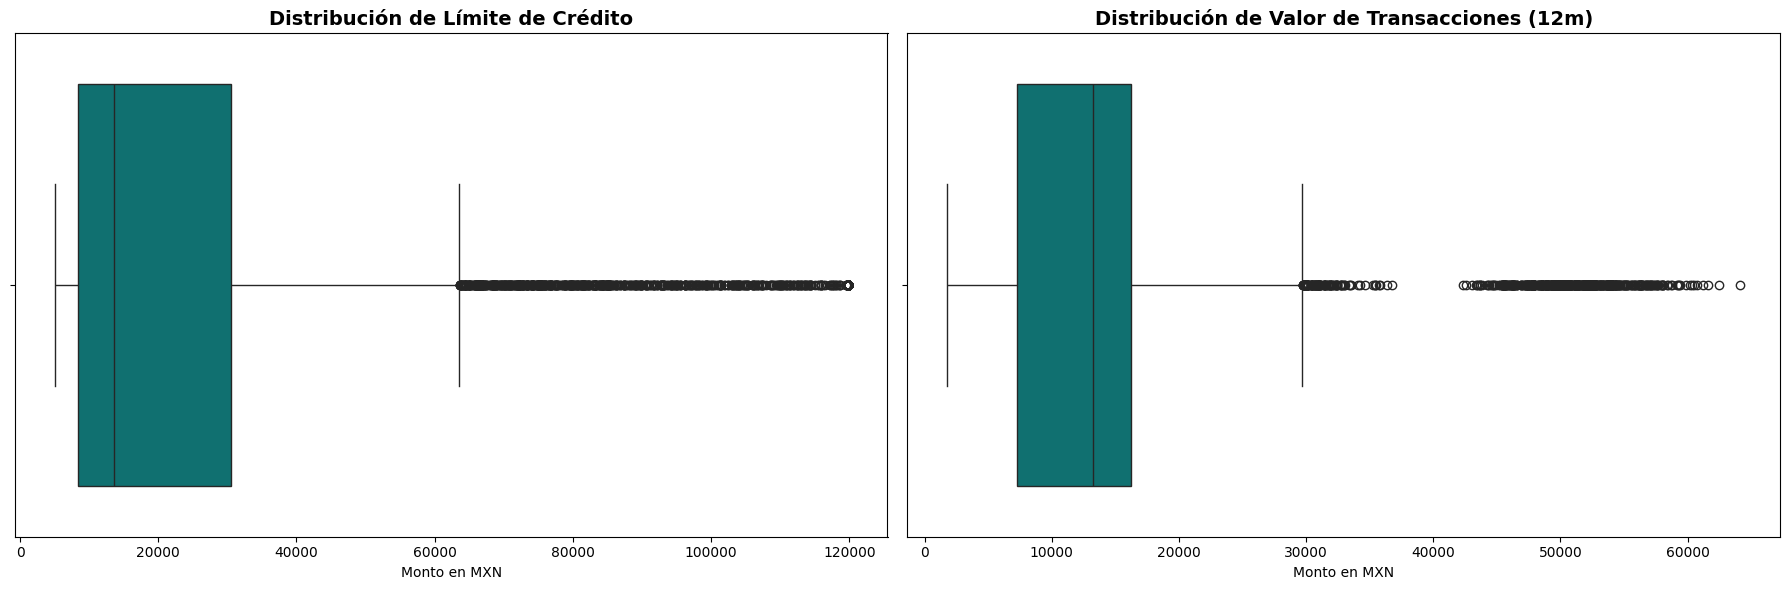

In [174]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes = axes.flatten()

# Gráfico 1: Límite de Crédito
sns.boxplot(x=df['limite_credito'], ax=axes[0], color='teal')
axes[0].set_title('Distribución de Límite de Crédito', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Monto en MXN')

# Gráfico 2: Valor de Transacciones
sns.boxplot(x=df['valor_transacciones_12m'], ax=axes[1], color='teal')
axes[1].set_title('Distribución de Valor de Transacciones (12m)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Monto en MXN')

plt.tight_layout()
plt.show()

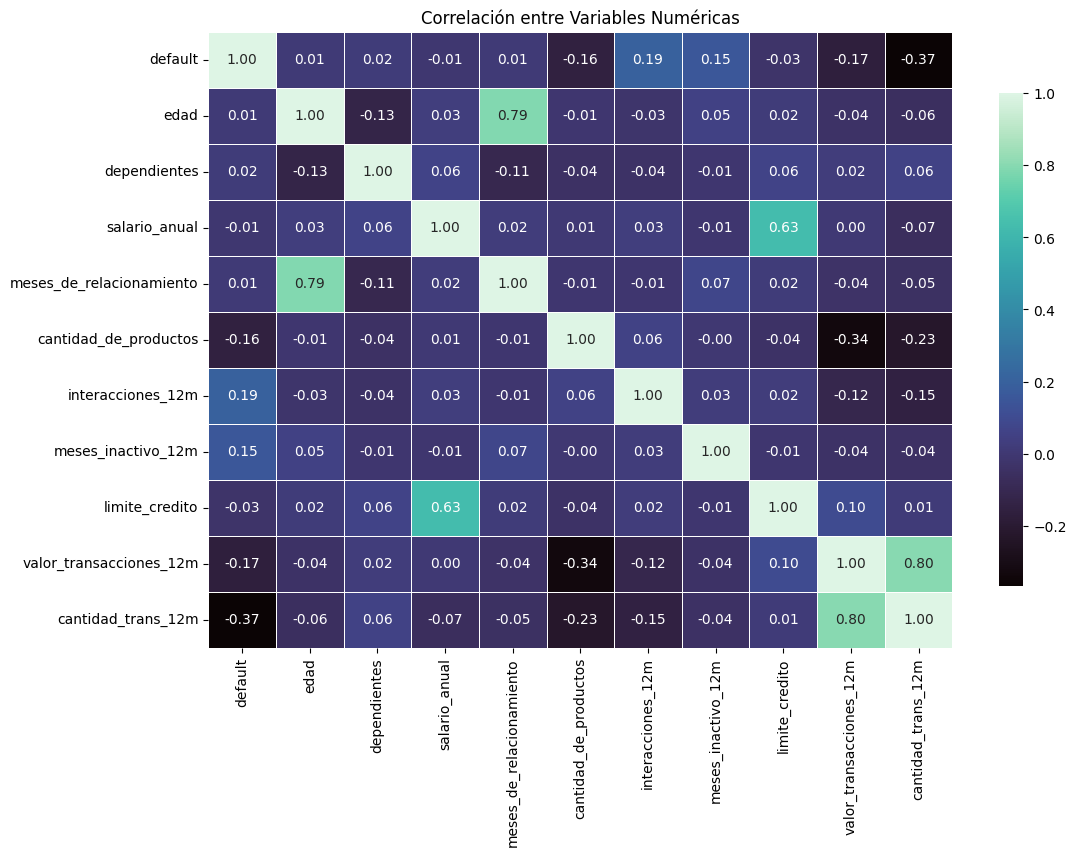

In [175]:
#análisis de importancia de variables
# Calcular la correlación entre variables numéricas
numeric_cols = ['default', 'edad', 'dependientes', 'salario_anual', 'meses_de_relacionamiento', 'cantidad_de_productos', 'interacciones_12m', 'meses_inactivo_12m', 'limite_credito', 'valor_transacciones_12m', 'cantidad_trans_12m']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='mako', fmt=".2f",linewidths=0.5,
            cbar_kws={"shrink": .8})
plt.title('Correlación entre Variables Numéricas')
plt.show()


/tmp/ipython-input-2225262417.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=['sexo', 'escolaridad', 'estado_civil'], palette='mako')


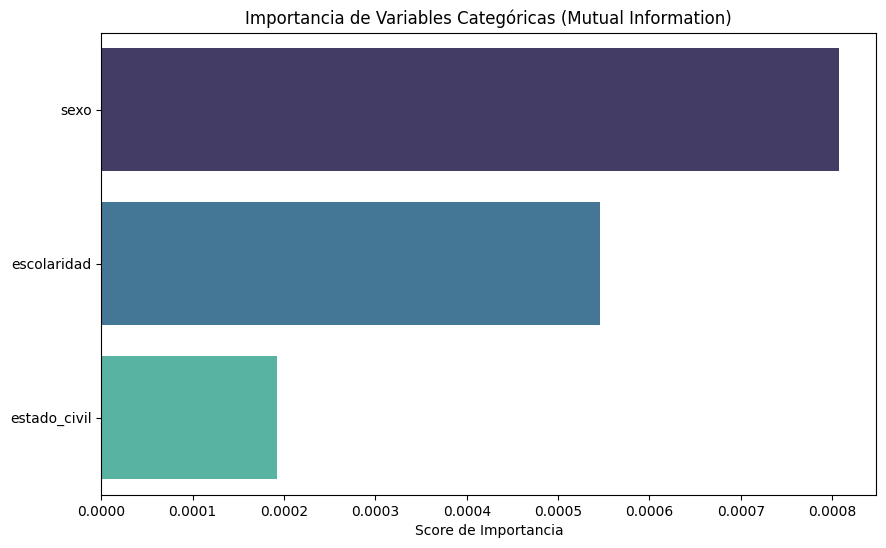

In [176]:
# analisis de importancia de variables cualitativas
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Codificamos las variables categóricas para el cálculo
df_cat = df[['sexo', 'escolaridad', 'estado_civil']].apply(LabelEncoder().fit_transform)
target = df['default']

# Calcular Mutual Information
importances = mutual_info_classif(df_cat, target, discrete_features=True)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=['sexo', 'escolaridad', 'estado_civil'], palette='mako')
plt.title('Importancia de Variables Categóricas (Mutual Information)')
plt.xlabel('Score de Importancia')
plt.show()

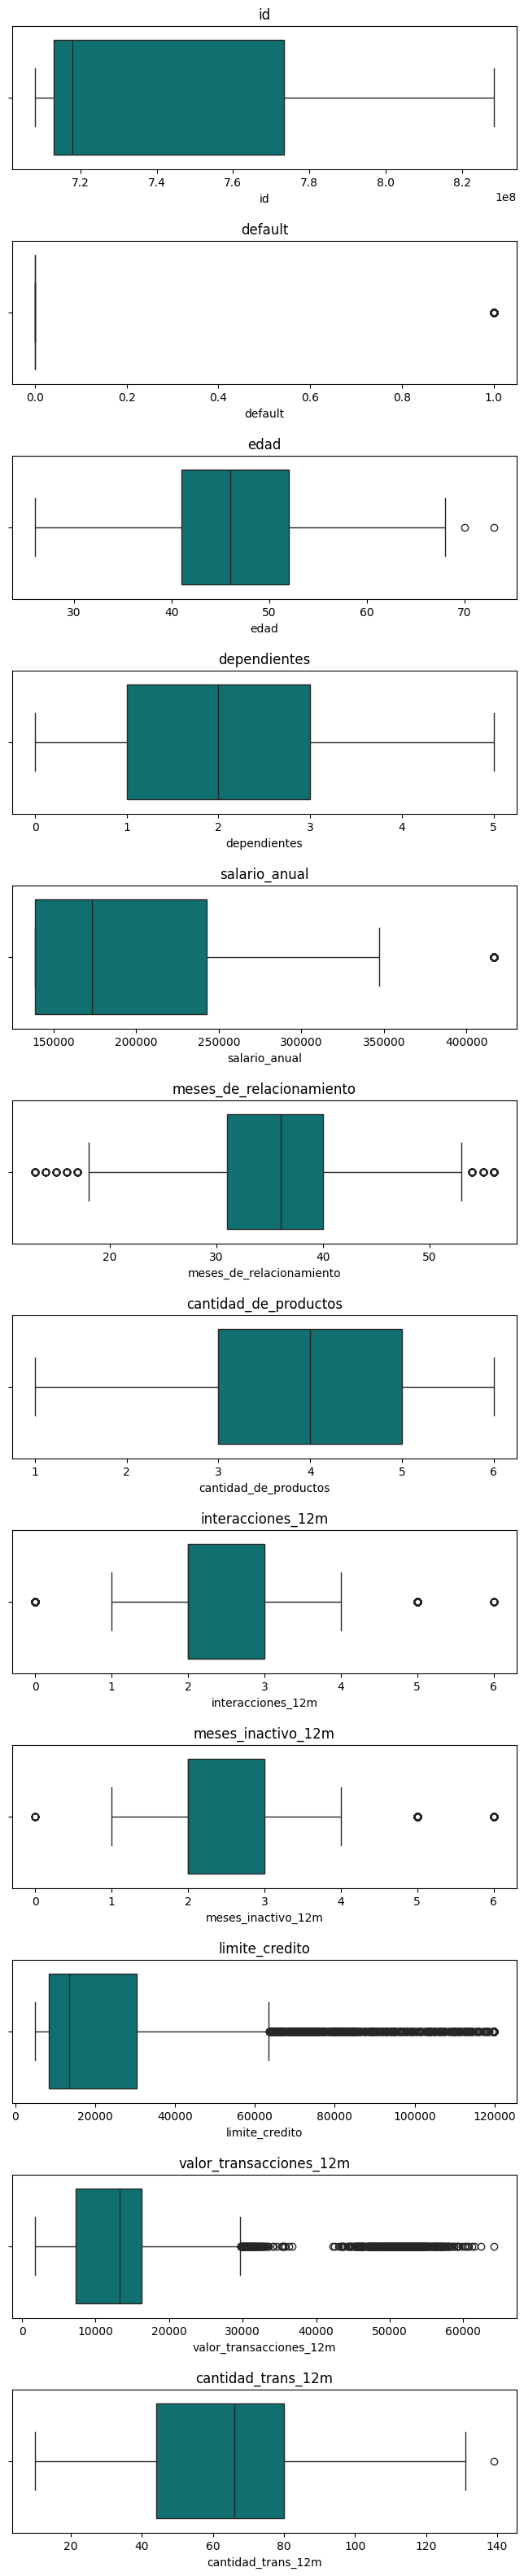

In [177]:
fig, ax = plt.subplots(nrows=12, ncols=1, figsize=(8, 40))
fig.subplots_adjust(hspace=0.5)

numeric_cols = ['id', 'default', 'edad', 'dependientes', 'salario_anual', 'meses_de_relacionamiento', 'cantidad_de_productos', 'interacciones_12m', 'meses_inactivo_12m', 'limite_credito', 'valor_transacciones_12m', 'cantidad_trans_12m']
for i, col in enumerate(numeric_cols):
    sns.boxplot( x=col, data = df,  ax=ax[i],color='teal')
    ax[i].set_title(col)
plt.show()

In [178]:
df_limpio = df
df_limpio.shape

(8391, 16)

In [179]:
ruta = '/content/drive/MyDrive/P/credito_limpio2.csv'
df_limpio.to_csv(ruta)

#**MODELOS**

In [180]:
credito_limpio2 = pd.read_csv('/content/drive/MyDrive/P/credito_limpio2.csv')

In [181]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, mean_absolute_error

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [182]:
# Antes de dividir en test y train, debemos codificar las variables categóricas.
# Convertir variables categóricas a numéricas usando one-hot encoding
X = pd.get_dummies(credito_limpio2.drop('default', axis=1), columns=['sexo', 'escolaridad', 'estado_civil', 'tipo_de_tarjeta'], drop_first=True)
y = credito_limpio2['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# llamar a los modelos
mod_log = LogisticRegression(max_iter=1000) # Incrementar max_iter para evitar convergencia
mod_tree = DecisionTreeClassifier()
mod_forest = RandomForestClassifier()




In [183]:
#funcion para hacer los modelos con validacion cruzada
def modelo(X_train, y_train, estimator_template):
  cv_maes = []
  # iniciar KFold
  kf = KFold(n_splits=5, shuffle=True, random_state=42)

  print(f'Validación cruzada con: {estimator_template.__class__.__name__}')
  for train_idx, val_idx in kf.split(X_train, y_train):
    X_fold, y_fold = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]


    current_estimator = estimator_template.__class__(**estimator_template.get_params())
    current_estimator.fit(X_fold, y_fold)
    y_pred_val = current_estimator.predict(X_val)
    mae_val = mean_absolute_error(y_val, y_pred_val)
    cv_maes.append(mae_val)


  final_model = estimator_template.__class__(**estimator_template.get_params())
  final_model.fit(X_train, y_train)


  y_pred_test = final_model.predict(X_test)
  y_pred_prob_test = final_model.predict_proba(X_test)[:, 1]

  print(f'\n--- Resultados para {estimator_template.__class__.__name__} ---')
  print(f'MAE promedio: {np.mean(cv_maes):.4f}')
  print(f'\nMatriz de confusion: \n {confusion_matrix(y_test, y_pred_test)}')
  print(f'\nReporte de clasificación: \n {classification_report(y_test, y_pred_test)}')
  print(f'AUC Score (Test Set): {roc_auc_score(y_test, y_pred_prob_test):.4f}')
  print('--------------------------------------------------------------------------------')

MODELOS SIN BALANCEO

In [184]:
modelo(X_train, y_train, mod_log)

Validación cruzada con: LogisticRegression

--- Resultados para LogisticRegression ---
MAE promedio: 0.0897

Matriz de confusion: 
 [[1383   43]
 [  73  180]]

Reporte de clasificación: 
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      1426
           1       0.81      0.71      0.76       253

    accuracy                           0.93      1679
   macro avg       0.88      0.84      0.86      1679
weighted avg       0.93      0.93      0.93      1679

AUC Score (Test Set): 0.9607
--------------------------------------------------------------------------------


In [185]:
modelo(X_train, y_train, mod_tree)

Validación cruzada con: DecisionTreeClassifier

--- Resultados para DecisionTreeClassifier ---
MAE promedio: 0.0308

Matriz de confusion: 
 [[1397   29]
 [  25  228]]

Reporte de clasificación: 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1426
           1       0.89      0.90      0.89       253

    accuracy                           0.97      1679
   macro avg       0.93      0.94      0.94      1679
weighted avg       0.97      0.97      0.97      1679

AUC Score (Test Set): 0.9404
--------------------------------------------------------------------------------


In [186]:
modelo(X_train, y_train, mod_forest)

Validación cruzada con: RandomForestClassifier

--- Resultados para RandomForestClassifier ---
MAE promedio: 0.0206

Matriz de confusion: 
 [[1414   12]
 [  17  236]]

Reporte de clasificación: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1426
           1       0.95      0.93      0.94       253

    accuracy                           0.98      1679
   macro avg       0.97      0.96      0.97      1679
weighted avg       0.98      0.98      0.98      1679

AUC Score (Test Set): 0.9945
--------------------------------------------------------------------------------


# **BALANCEADO DE DATOS**

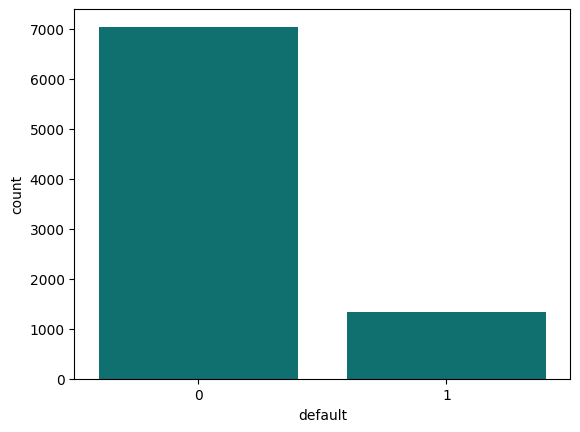

In [187]:
# Mostrar la grafica del conteo de los defaults
sns.countplot(x='default', data=credito_limpio2, color= 'teal')
plt.show()


In [188]:
count_class_1 = len(credito_limpio2[credito_limpio2['default'] == 1])
count_class_1


1343

OVERSAMPLING - UNDERSAMPLING

In [189]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

In [190]:
X, y = X_train, y_train

over = RandomOverSampler(sampling_strategy= 1)
under = RandomUnderSampler(sampling_strategy= 1)

X_over, y_over = over.fit_resample(X, y)
X_under, y_under = under.fit_resample(X, y)

In [191]:
y_over.value_counts()*100/len(y_over)

,count
default,
0,50.0
1,50.0


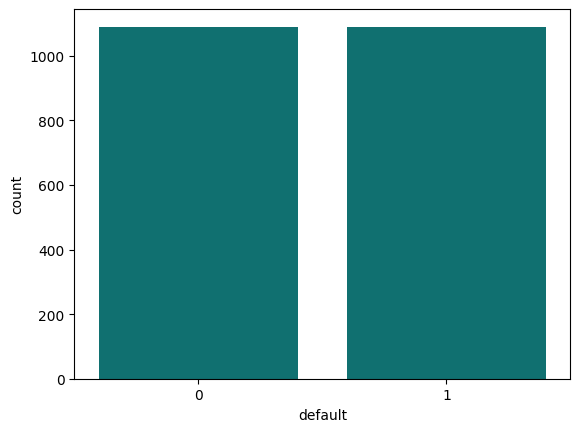

In [192]:
# histograma de default ya balanceado
sns.countplot(x='default', data=pd.DataFrame(y_under), color= 'teal')
plt.show()

MODELOS CON BALANCEO DE DATOS
(OVERSAMPLE)

In [193]:
modelo(X_over, y_over, mod_log)

Validación cruzada con: LogisticRegression

--- Resultados para LogisticRegression ---
MAE promedio: 0.2137

Matriz de confusion: 
 [[1265  161]
 [  27  226]]

Reporte de clasificación: 
               precision    recall  f1-score   support

           0       0.98      0.89      0.93      1426
           1       0.58      0.89      0.71       253

    accuracy                           0.89      1679
   macro avg       0.78      0.89      0.82      1679
weighted avg       0.92      0.89      0.90      1679

AUC Score (Test Set): 0.9602
--------------------------------------------------------------------------------


In [194]:
modelo(X_over, y_over, mod_tree)

Validación cruzada con: DecisionTreeClassifier

--- Resultados para DecisionTreeClassifier ---
MAE promedio: 0.0091

Matriz de confusion: 
 [[1399   27]
 [  20  233]]

Reporte de clasificación: 
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      1426
           1       0.90      0.92      0.91       253

    accuracy                           0.97      1679
   macro avg       0.94      0.95      0.95      1679
weighted avg       0.97      0.97      0.97      1679

AUC Score (Test Set): 0.9510
--------------------------------------------------------------------------------


In [195]:
modelo(X_over, y_over, mod_forest)

Validación cruzada con: RandomForestClassifier

--- Resultados para RandomForestClassifier ---
MAE promedio: 0.0063

Matriz de confusion: 
 [[1407   19]
 [  10  243]]

Reporte de clasificación: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1426
           1       0.93      0.96      0.94       253

    accuracy                           0.98      1679
   macro avg       0.96      0.97      0.97      1679
weighted avg       0.98      0.98      0.98      1679

AUC Score (Test Set): 0.9930
--------------------------------------------------------------------------------


MODELOS CON UNDERSAMPLE

In [196]:
modelo(X_under, y_under, mod_log)

Validación cruzada con: LogisticRegression

--- Resultados para LogisticRegression ---
MAE promedio: 0.2124

Matriz de confusion: 
 [[1274  152]
 [  28  225]]

Reporte de clasificación: 
               precision    recall  f1-score   support

           0       0.98      0.89      0.93      1426
           1       0.60      0.89      0.71       253

    accuracy                           0.89      1679
   macro avg       0.79      0.89      0.82      1679
weighted avg       0.92      0.89      0.90      1679

AUC Score (Test Set): 0.9604
--------------------------------------------------------------------------------


In [197]:
modelo(X_under, y_under, mod_tree)

Validación cruzada con: DecisionTreeClassifier

--- Resultados para DecisionTreeClassifier ---
MAE promedio: 0.0450

Matriz de confusion: 
 [[1359   67]
 [  11  242]]

Reporte de clasificación: 
               precision    recall  f1-score   support

           0       0.99      0.95      0.97      1426
           1       0.78      0.96      0.86       253

    accuracy                           0.95      1679
   macro avg       0.89      0.95      0.92      1679
weighted avg       0.96      0.95      0.96      1679

AUC Score (Test Set): 0.9548
--------------------------------------------------------------------------------


In [198]:
modelo(X_under, y_under, mod_forest)

Validación cruzada con: RandomForestClassifier

--- Resultados para RandomForestClassifier ---
MAE promedio: 0.0289

Matriz de confusion: 
 [[1383   43]
 [   8  245]]

Reporte de clasificación: 
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      1426
           1       0.85      0.97      0.91       253

    accuracy                           0.97      1679
   macro avg       0.92      0.97      0.94      1679
weighted avg       0.97      0.97      0.97      1679

AUC Score (Test Set): 0.9931
--------------------------------------------------------------------------------
